

 * STEP 1 — Dataset Setup (DJI Mini — Validation Build)
 * Maps 1:1 with the original notebook structure so this cell
 * can be swapped into the full 6-class project later.


In [ ]:
# --- 1A. Install dependencies ---
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.9 MB/s eta 0:00:00


In [ ]:

# --- 1B. Download DJI dataset from Roboflow ---
from roboflow import Roboflow
from pathlib import Path


rf = Roboflow(api_key="eviBQlQLcnDopYhKqk0s")
project  = rf.workspace("ranas-workspace-u6ewi").project("dji-neo-iaga8-zkbef")
version  = project.version(2)
dataset  = version.download("yolo26")

# dataset.location is where Roboflow saved it (e.g. /content/dji-neo-iaga8-zkbef-2)
data_path = Path(dataset.location)
print("Dataset saved at:", data_path)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DJI-NEO-2 in yolo26:: 100%|██████████| 3467/3467 [00:01<00:00, 2842.14it/s]

Dataset saved at: /content/DJI-NEO-2


In [ ]:
from pathlib import Path

# --- 1C. Find data.yaml (same logic as original) ---
yaml_candidates = list(data_path.rglob("data.yaml"))
if not yaml_candidates:
    raise FileNotFoundError("data.yaml not found — check dataset location")

YAML_PATH = yaml_candidates[0]
print(f"\ndata.yaml found at: {YAML_PATH}")
print(YAML_PATH.read_text())



data.yaml found at: /content/DJI-NEO-2/data.yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['dji']

roboflow:
  workspace: ranas-workspace-u6ewi
  project: dji-neo-iaga8-zkbef
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/ranas-workspace-u6ewi/dji-neo-iaga8-zkbef/dataset/2


In [ ]:
import yaml

# --- 1D. Patch data.yaml so class name is 'dji' ---
# Roboflow may name it differently; we normalise it here.
with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

# Force single class name to match future 6-class slot #2 ("dji")
cfg["names"] = ["dji"]
cfg["nc"]    = 1

with open(YAML_PATH, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

print("\n[Patched] data.yaml updated:")
print(YAML_PATH.read_text())


[Patched] data.yaml updated:
names:
- dji
nc: 1
roboflow:
  license: CC BY 4.0
  project: dji-neo-iaga8-zkbef
  url: https://universe.roboflow.com/ranas-workspace-u6ewi/dji-neo-iaga8-zkbef/dataset/2
  version: 2
  workspace: ranas-workspace-u6ewi
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
# Quick scan — find all label files under the dataset folder
import subprocess
result = subprocess.run(
    ["find", "/content/DJI-NEO-2", "-name", "*.txt", "-not", "-name", "*.yaml"],
    capture_output=True, text=True
)
print(result.stdout[:3000])  # first 3000 chars is enough


/content/DJI-NEO-2/README.dataset.txt
/content/DJI-NEO-2/README.roboflow.txt
/content/DJI-NEO-2/train/labels/DSC_0716_JPG.rf.21ac7c8aa18f76cb8ff6b25dfb84b120.txt
/content/DJI-NEO-2/train/labels/DSC_0843_JPG.rf.e7bf96e2c2e2987a8cb3b3186f033138.txt
/content/DJI-NEO-2/train/labels/DSC_0850_JPG.rf.4befc4fbbf69ff54428de28117fefbdc.txt
/content/DJI-NEO-2/train/labels/DSC_0668_JPG.rf.5616a7180e8759403ae351c08074632b.txt
/content/DJI-NEO-2/train/labels/DSC_0826_JPG.rf.68f1e90d79c56b54932100ff47aa5098.txt
/content/DJI-NEO-2/train/labels/DSC_0894_JPG.rf.b782d1b27dfd94e9556ba6c0b5d486f0.txt
/content/DJI-NEO-2/train/labels/DSC_0652_JPG.rf.caed985147100c1cd6519c9c2b10de2e.txt
/content/DJI-NEO-2/train/labels/DSC_0770_JPG.rf.a0ea9272d74bfccd8f0b175ceb70e46d.txt
/content/DJI-NEO-2/train/labels/photo_20251004_164649_jpg.rf.4f74af7b14a88de21114ae3867832db0.txt
/content/DJI-NEO-2/train/labels/photo_20251004_164712_jpg.rf.2fa7efe9459baa3c334f1818a90e8c0d.txt
/content/DJI-NEO-2/train/labels/DSC_0841_JPG.rf

In [ ]:
# ============================================================
# STEP 2A — Fix data.yaml paths + Class Distribution Check
# ============================================================

import yaml
from pathlib import Path
from collections import defaultdict

# --- Fix data.yaml paths to match actual structure ---
with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

cfg["train"] = "train/images"
cfg["val"]   = "valid/images"
cfg["test"]  = "test/images"

with open(YAML_PATH, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

print("data.yaml paths fixed:")
print(YAML_PATH.read_text())

# --- Class distribution count ---
class_names  = cfg.get("names", [])
dataset_root = YAML_PATH.parent   # /content/DJI-NEO-2/

splits = {
    "train": cfg.get("train", ""),
    "val":   cfg.get("val",   ""),
    "test":  cfg.get("test",  ""),
}

grand_total = defaultdict(int)

for split_name, split_path in splits.items():
    if not split_path:
        continue
    labels_dir = (dataset_root / split_path.replace("/images", "/labels")).resolve()

    if not labels_dir.exists():
        print(f"[{split_name}] labels dir not found: {labels_dir}")
        continue

    split_counts = defaultdict(int)
    label_files  = list(labels_dir.rglob("*.txt"))

    for lf in label_files:
        classes_in_file = set()
        for line in lf.read_text().strip().splitlines():
            parts = line.strip().split()
            if parts:
                classes_in_file.add(int(parts[0]))
        for cls_id in classes_in_file:
            split_counts[cls_id] += 1

    print(f"\n[{split_name.upper()}]  ({len(label_files)} label files)")
    print(f"  {'Class':<20} {'ID':>4}  {'Images':>8}")
    print(f"  {'-'*20}  {'-'*4}  {'-'*8}")
    for cls_id in sorted(split_counts):
        name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
        print(f"  {name:<20} {cls_id:>4}  {split_counts[cls_id]:>8}")
        grand_total[cls_id] += split_counts[cls_id]

print(f"\n[ALL SPLITS COMBINED]")
print(f"  {'Class':<20} {'ID':>4}  {'Images':>8}")
print(f"  {'-'*20}  {'-'*4}  {'-'*8}")
for cls_id in sorted(grand_total):
    name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
    print(f"  {name:<20} {cls_id:>4}  {grand_total[cls_id]:>8}")

data.yaml paths fixed:
names:
- dji
nc: 1
roboflow:
  license: CC BY 4.0
  project: dji-neo-iaga8-zkbef
  url: https://universe.roboflow.com/ranas-workspace-u6ewi/dji-neo-iaga8-zkbef/dataset/2
  version: 2
  workspace: ranas-workspace-u6ewi
test: test/images
train: train/images
val: valid/images


[TRAIN]  (1548 label files)
  Class                  ID    Images
  --------------------  ----  --------
  dji                     0      1532

[VAL]  (122 label files)
  Class                  ID    Images
  --------------------  ----  --------
  dji                     0       122

[TEST]  (61 label files)
  Class                  ID    Images
  --------------------  ----  --------
  dji                     0        61

[ALL SPLITS COMBINED]
  Class                  ID    Images
  --------------------  ----  --------
  dji                     0      1715


In [ ]:
# ============================================================
# STEP 2B — Checkpoint Configuration
# Mirrors weights to Drive after every run.
# Identical to original — only run name changed.
# ============================================================

import shutil
from pathlib import Path

DRIVE_CKPT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/yolo26n_dji_checkpoints")
LOCAL_RUN_DIR  = Path("/content/runs/detect/drone_runs/yolo26n_dji")
LOCAL_CKPT_DIR = LOCAL_RUN_DIR / "weights"

DRIVE_CKPT_DIR.mkdir(parents=True, exist_ok=True)

drive_last = DRIVE_CKPT_DIR / "last.pt"
drive_best = DRIVE_CKPT_DIR / "best.pt"

if drive_last.exists():
    LOCAL_CKPT_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copy(drive_last, LOCAL_CKPT_DIR / "last.pt")
    if drive_best.exists():
        shutil.copy(drive_best, LOCAL_CKPT_DIR / "best.pt")
    RESUME = True
    print("Checkpoint found in Drive — resuming from last saved epoch.")
    print(f"  last.pt restored to: {LOCAL_CKPT_DIR / 'last.pt'}")
else:
    RESUME = False
    print("No checkpoint found — starting from pretrained yolo26n weights.")

SAVE_PERIOD = 5

No checkpoint found — starting from pretrained yolo26n weights.


In [ ]:
# ============================================================
# STEP 2C — Training
# Same structure as original. 1-class DJI fine-tune.
# When ready to merge into the 6-class project, only the
# data/name args change — the rest is identical.
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import shutil

LOCAL_LAST = LOCAL_CKPT_DIR / "last.pt"

if RESUME and LOCAL_LAST.exists():
    model = YOLO(str(LOCAL_LAST))
    print(f"Resuming from: {LOCAL_LAST}")
    train_kwargs = dict(
        resume      = True,
        data        = str(YAML_PATH),
        epochs      = 50,
        imgsz       = 640,
        batch       = 16,
        project     = "drone_runs",
        name        = "yolo26n_dji",
        exist_ok    = True,
        patience    = 15,
        cache       = False,
        device      = "0",
        verbose     = True,
        save        = True,
        save_period = SAVE_PERIOD,
    )
else:
    model = YOLO("yolo26n.pt")
    print(f"Model : YOLO26n")
    print(f"Params: {sum(p.numel() for p in model.model.parameters()):,}")
    train_kwargs = dict(
        data        = str(YAML_PATH),
        epochs      = 50,          # more than original 10 — DJI dataset is small
        imgsz       = 640,
        batch       = 16,
        project     = "drone_runs",
        name        = "yolo26n_dji",
        exist_ok    = True,
        patience    = 15,
        cache       = False,
        device      = "0",
        verbose     = True,
        save        = True,
        save_period = SAVE_PERIOD,
    )

results = model.train(**train_kwargs)

# Mirror weights to Drive immediately
weights_src = Path(results.save_dir) / "weights"
for pt_file in weights_src.glob("*.pt"):
    shutil.copy(pt_file, DRIVE_CKPT_DIR / pt_file.name)
    print(f"Saved to Drive: {DRIVE_CKPT_DIR / pt_file.name}")

BEST_WEIGHTS = weights_src / "best.pt"
print(f"\nTraining complete. Best weights -> {BEST_WEIGHTS}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model : YOLO26n
Params: 2,572,280
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DJI-NEO-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0

In [ ]:
# ============================================================
# STEP 3A — Evaluation
# Same structure as original notebook.
# ============================================================

from ultralytics import YOLO
import json, shutil
from pathlib import Path

eval_model = YOLO(str(BEST_WEIGHTS))

metrics = eval_model.val(
    data    = str(YAML_PATH),
    imgsz   = 640,
    device  = "0",
    verbose = True,
)

eval_summary = {
    "mAP50"    : round(float(metrics.box.map50), 4),
    "mAP50-95" : round(float(metrics.box.map),   4),
    "Precision": round(float(metrics.box.mp),    4),
    "Recall"   : round(float(metrics.box.mr),    4),
}

print("\n" + "="*45)
print("  Evaluation Results  (YOLO26n — DJI)")
print("="*45)
for k, v in eval_summary.items():
    bar = "#" * int(v * 30)
    print(f"  {k:<12}: {v:.4f}  {bar}")
print("="*45)

eval_json_path = Path("eval_results.json")
eval_json_path.write_text(json.dumps(eval_summary, indent=2))
shutil.copy(eval_json_path, DRIVE_CKPT_DIR / "eval_results.json")
print(f"eval_results.json saved locally and to Drive.")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1384.6±366.4 MB/s, size: 63.0 KB)
val: Scanning /content/DJI-NEO-2/valid/labels.cache... 122 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122 36.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.6it/s 3.1s
                   all        122        122      0.912      0.869       0.92      0.673
Speed: 4.5ms preprocess, 7.7ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val

  Evaluation Results  (YOLO26n — DJI)
  mAP50       : 0.9203  ###########################
  mAP50-95    : 0.6732  ####################
  Precision   : 0.9116  ###########################
  Recall      : 0.8689  ##########################
eval_results.json saved locally and to 

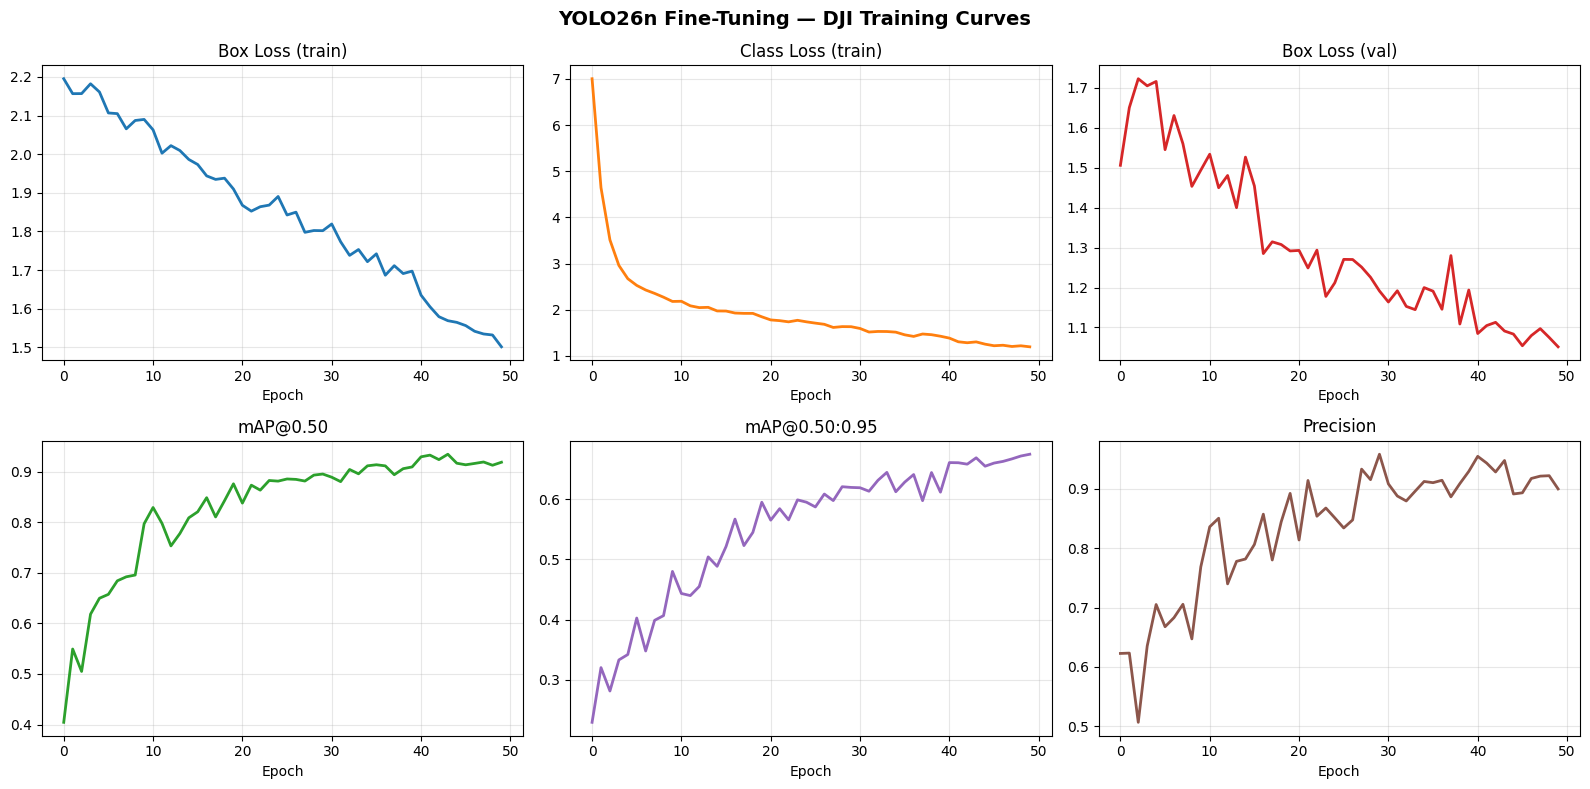

Training curves saved -> training_curves_dji.png


In [ ]:
# ============================================================
# STEP 3B — Training Curves
# Same as original notebook.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/content/runs/detect/drone_runs/yolo26n_dji/results.csv")

if csv_path.exists():
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("YOLO26n Fine-Tuning — DJI Training Curves", fontsize=14, fontweight="bold")

    plot_pairs = [
    ("train/box_loss",         "Box Loss (train)",   "tab:blue"),
    ("train/cls_loss",         "Class Loss (train)", "tab:orange"),
    ("val/box_loss",           "Box Loss (val)",     "tab:red"),
    ("metrics/mAP50(B)",       "mAP@0.50",           "tab:green"),
    ("metrics/mAP50-95(B)",    "mAP@0.50:0.95",      "tab:purple"),
    ("metrics/precision(B)",   "Precision",          "tab:brown"),
]

    for ax, (col, title, color) in zip(axes.flat, plot_pairs):
        if col in df.columns:
            ax.plot(df[col], color=color, linewidth=2)
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f"{col}\nnot found", ha="center", va="center")

    plt.tight_layout()
    plt.savefig("training_curves_dji.png", dpi=120)
    plt.show()
    print("Training curves saved -> training_curves_dji.png")
else:
    print(f"results.csv not found at {csv_path} — run training cell first")

In [ ]:
# ============================================================
# STEP 3C — Manual Backup
# Same as original — run anytime to push weights to Drive.
# ============================================================

import shutil
from pathlib import Path

def backup_checkpoints_to_drive():
    backed_up = []
    for fname in ["last.pt", "best.pt"]:
        src = LOCAL_CKPT_DIR / fname
        dst = DRIVE_CKPT_DIR / fname
        if src.exists():
            shutil.copy(src, dst)
            backed_up.append(fname)
    if backed_up:
        print(f"Backed up to Drive: {backed_up}")
    else:
        print("No checkpoint files found yet.")

backup_checkpoints_to_drive()

No checkpoint files found yet.


## Tracking (byteTrack)

In [ ]:
# ============================================================
# STEP 4A — Tracker Setup
# ByteTrack via YOLO .track() — assigns persistent track IDs
# across frames. No extra install needed, built into ultralytics.
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import json

# Load the trained DJI weights
BEST_WEIGHTS = Path("/content/runs/detect/drone_runs/yolo26n_dji/weights/best.pt")
track_model  = YOLO(str(BEST_WEIGHTS))

CLASS_NAMES = track_model.names   # {0: 'dji'}
print("Model loaded. Classes:", CLASS_NAMES)

# ---- Tracker config (ByteTrack) ----
# We write a small yaml so we can tune it later without changing code
TRACKER_CFG = Path("/content/bytetrack_dji.yaml")
TRACKER_CFG.write_text("""
tracker_type: bytetrack
track_high_thresh: 0.35
track_low_thresh: 0.05
new_track_thresh: 0.35
track_buffer: 30
match_thresh: 0.8
fuse_score: True
""")
print(f"Tracker config written -> {TRACKER_CFG}")

# ---- Sensitive areas for ETA (demo — random Riyadh coords) ----
# Each entry: {"name": str, "lat": float, "lon": float}
SENSITIVE_AREAS = [
    {"name": "Area-A", "lat": 24.7136, "lon": 46.6753},
    {"name": "Area-B", "lat": 24.6877, "lon": 46.7219},
    {"name": "Area-C", "lat": 24.7441, "lon": 46.6180},
    {"name": "Area-D", "lat": 24.6600, "lon": 46.7100},
    {"name": "Area-E", "lat": 24.7900, "lon": 46.6400},
]
print(f"Sensitive areas loaded: {len(SENSITIVE_AREAS)} sites")

Model loaded. Classes: {0: 'dji'}
Tracker config written -> /content/bytetrack_dji.yaml
Sensitive areas loaded: 5 sites


In [ ]:
# ============================================================
# STEP 4B — SDB Tracking Loop
# For each frame computes:
#   1. Drone type       — from class name
#   2. Location (px)    — bbox center (lat/lon via monocular fallback)
#   3. Speed            — px/frame between track positions
#   4. Direction        — angle in degrees (0=right, 90=up)
#   5. ETA              — estimated seconds to nearest sensitive area
#
# Output: annotated video + sdb_log.json
# ============================================================

import cv2
import math
import json
import numpy as np
from pathlib import Path
from collections import defaultdict
from datetime import datetime

# ---- Config ----
# Set your video path here — can be uploaded to Colab or on Drive
VIDEO_IN  = "/content/djiVid1.mp4"   # ← change this
VIDEO_OUT = "/content/tracked_output.mp4"
SDB_LOG   = "/content/sdb_log.json"

# Camera / scene assumptions (monocular fallback)
# Raspberry Pi cam or DJI cam looking down at ~known altitude
ASSUMED_ALTITUDE_M  = 50.0     # metres — adjust for your demo setup
SENSOR_WIDTH_PX     = 1280     # frame width you expect
FOV_DEG             = 82.6     # horizontal FoV (RPi cam v2 default)
FRAME_RATE          = 30.0     # fps of input video

# Anchor: centre of frame maps to this real-world coordinate
# For demo we use a random Riyadh point as "camera position"
CAM_LAT = 24.7136
CAM_LON = 46.6753

# ---- Helpers ----
def px_to_meters(px_delta):
    """Convert pixel displacement to metres using monocular assumption."""
    meters_per_px = (2 * ASSUMED_ALTITUDE_M * math.tan(math.radians(FOV_DEG / 2))) / SENSOR_WIDTH_PX
    return px_delta * meters_per_px

def px_to_latlon(cx, cy, frame_w, frame_h):
    """Map pixel centre to approximate lat/lon."""
    meters_per_px = (2 * ASSUMED_ALTITUDE_M * math.tan(math.radians(FOV_DEG / 2))) / frame_w
    dx_m = (cx - frame_w / 2) * meters_per_px
    dy_m = (cy - frame_h / 2) * meters_per_px
    lat = CAM_LAT + (dy_m / 111320)
    lon = CAM_LON + (dx_m / (111320 * math.cos(math.radians(CAM_LAT))))
    return round(lat, 6), round(lon, 6)

def haversine_m(lat1, lon1, lat2, lon2):
    """Distance in metres between two lat/lon points."""
    R = 6_371_000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi  = math.radians(lat2 - lat1)
    dlam  = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def calc_eta(lat, lon, speed_mps):
    """Return (nearest_area_name, distance_m, eta_seconds)."""
    best_name, best_dist = None, float("inf")
    for area in SENSITIVE_AREAS:
        d = haversine_m(lat, lon, area["lat"], area["lon"])
        if d < best_dist:
            best_dist = d
            best_name = area["name"]
    eta = (best_dist / speed_mps) if speed_mps > 0.5 else float("inf")
    return best_name, round(best_dist, 1), round(eta, 1)

# ---- Track history store ----
# track_id -> list of (cx, cy) per frame
track_history   = defaultdict(list)
track_latlon    = defaultdict(list)
sdb_records     = []

# ---- Video I/O ----
cap = cv2.VideoCapture(VIDEO_IN)
if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {VIDEO_IN}")

frame_w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_src   = cap.get(cv2.CAP_PROP_FPS) or FRAME_RATE
fourcc    = cv2.VideoWriter_fourcc(*"mp4v")
out       = cv2.VideoWriter(VIDEO_OUT, fourcc, fps_src, (frame_w, frame_h))

print(f"Input  : {VIDEO_IN}  ({frame_w}x{frame_h} @ {fps_src:.1f}fps)")
print(f"Output : {VIDEO_OUT}")
print("Processing frames...")

frame_idx = 0

for result in track_model.track(
    source      = VIDEO_IN,
    tracker     = str(TRACKER_CFG),
    conf        = 0.35,
    iou         = 0.45,
    imgsz       = 640,
    stream      = True,      # memory-safe frame-by-frame
    persist     = True,      # keep track IDs across frames
    verbose     = False,
):
    frame = result.orig_img.copy()

    if result.boxes is None or result.boxes.id is None:
        out.write(frame)
        frame_idx += 1
        continue

    boxes    = result.boxes.xyxy.cpu().numpy()
    track_ids = result.boxes.id.cpu().numpy().astype(int)
    confs    = result.boxes.conf.cpu().numpy()
    classes  = result.boxes.cls.cpu().numpy().astype(int)

    for box, tid, conf, cls_id in zip(boxes, track_ids, confs, classes):
        x1, y1, x2, y2 = map(int, box)
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2

        drone_type = CLASS_NAMES.get(cls_id, f"cls_{cls_id}")
        lat, lon   = px_to_latlon(cx, cy, frame_w, frame_h)

        # ---- Speed & Direction ----
        history = track_history[tid]
        history.append((cx, cy))
        if len(history) > 30:
            history.pop(0)

        if len(history) >= 2:
            dx = history[-1][0] - history[-2][0]
            dy = history[-1][1] - history[-2][1]
            speed_px  = math.hypot(dx, dy)
            speed_mps = px_to_meters(speed_px) * fps_src
            angle_deg = math.degrees(math.atan2(-dy, dx)) % 360   # -dy because y axis flipped
        else:
            speed_px  = 0.0
            speed_mps = 0.0
            angle_deg = 0.0

        # Direction label (8 compass points)
        compass = ["E","NE","N","NW","W","SW","S","SE"]
        direction = compass[int((angle_deg + 22.5) / 45) % 8]

        # ---- ETA ----
        nearest_area, dist_m, eta_s = calc_eta(lat, lon, speed_mps)

        # ---- Log ----
        sdb_records.append({
            "frame"       : frame_idx,
            "track_id"    : int(tid),
            "drone_type"  : drone_type,
            "confidence"  : round(float(conf), 3),
            "lat"         : lat,
            "lon"         : lon,
            "speed_mps"   : round(speed_mps, 2),
            "direction"   : direction,
            "angle_deg"   : round(angle_deg, 1),
            "nearest_area": nearest_area,
            "dist_m"      : dist_m,
            "eta_s"       : eta_s,
            "timestamp"   : datetime.utcnow().isoformat(),
        })

        # ---- Draw on frame ----
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 200, 255), 2)

        # Track trail
        for i in range(1, len(history)):
            cv2.line(frame, history[i-1], history[i], (0, 200, 255), 1)

        # SDB info panel
        eta_str = f"{eta_s:.0f}s" if eta_s != float("inf") else "---"
        lines = [
            f"ID:{tid}  {drone_type}  {conf:.0%}",
            f"Spd: {speed_mps:.1f} m/s  Dir: {direction}",
            f"Lat:{lat:.5f} Lon:{lon:.5f}",
            f"ETA->{nearest_area}: {eta_str} ({dist_m:.0f}m)",
        ]
        panel_y = y1 - 4 - len(lines) * 18
        for i, line in enumerate(lines):
            cv2.putText(frame, line, (x1, panel_y + i*18),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 3)
            cv2.putText(frame, line, (x1, panel_y + i*18),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 220, 255), 1)

    out.write(frame)
    frame_idx += 1
    if frame_idx % 100 == 0:
        print(f"  processed {frame_idx} frames...")

cap.release()
out.release()

# Save SDB log
Path(SDB_LOG).write_text(json.dumps(sdb_records, indent=2))
print(f"\nDone. {frame_idx} frames processed.")
print(f"Annotated video -> {VIDEO_OUT}")
print(f"SDB log         -> {SDB_LOG}  ({len(sdb_records)} records)")

Input  : /content/djiVid1.mp4  (670x1202 @ 30.0fps)
Output : /content/tracked_output.mp4
Processing frames...


NameError: name 'track_model' is not defined

In [ ]:
import subprocess
subprocess.run([
    "ffmpeg", "-y", "-i", "/content/tracked_output.mp4",
    "-vcodec", "libx264", "-crf", "23",
    "/content/tracked_output_x264.mp4"
], capture_output=True)
print("Done")

In [ ]:
from IPython.display import HTML
from base64 import b64encode

mp4 = open("/content/tracked_output_x264.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=464 height=848 controls autoplay><source src="{data_url}" type="video/mp4"></video>')